# Climate Change Team — Combined Data Investigation Notebook
## Part A: Week 2 (Define) — Data Cleaning & Visualization
## Part B: Week 4 (Prototype) — Machine Learning & Model Comparison

**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions

This notebook contains two work sessions from your Capstone Data Investigation, combined into a single file for easy reference:

- **Part A (Week 2, Wednesday):** Assess → Clean → Visualize → Tell the Story → HCD Design Sprint #2 (Problem Statement)
- **Part B (Week 4):** Define target → Feature engineering → Baseline → Multi-algorithm comparison → Fairness check → HCD Design Sprint #4 (Prototype)

**Run Part A first, top to bottom** — it produces the cleaned dataset and saved CSV that Part B depends on. Part B also includes a fallback that re-cleans from scratch if you skip straight to it, but running Part A first is strongly recommended so your cleaning decisions carry through consistently.

---


---
# PART A — Week 2, Day 3 (Wednesday): Data Cleaning & Visualization + HCD Design Sprint #2
---

# Week 2, Day 3 (Wednesday) — Climate Change Team
## Colab Lab: Data Cleaning & Visualization + HCD Design Sprint #2

**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions
**HCD Phase:** Define — *"Name the problem precisely enough to act on it."*
**Today you will:** Assess → Clean → Visualize → Tell the Story → Write your team's Problem Statement

---

### Vocabulary you need before you start

| Term | Plain-English meaning |
|---|---|
| **Missing value** | A cell in the spreadsheet that is blank — the measurement was never collected, or doesn't apply. |
| **Outlier** | A data point far outside the normal range. Sometimes it's an error. Sometimes it's the most important data point in the whole dataset. |
| **Regional aggregate** | A row that isn't a real country — it's a *rollup* like "World," "Asia," or "European Union (27)." These will break a country-level analysis if you don't catch them. |
| **Data-ink ratio** | A design idea: every pixel of ink on a chart should carry information. Delete anything that doesn't. |
| **Finding-based title** | A chart title that states the *result*, not the *topic*. Not "CO2 by Country" — instead "China's per-person emissions have overtaken the EU's since 2005." |

> **Today's rule:** every time you drop a row, fill a blank, or pick a chart type, you must be able to say *why* in one sentence. "I felt like it" is not a justification. A data scientist's decisions are auditable.


# Warm-up discussion (no coding — 3 min)
Yesterday (Tuesday) we looked at charts that lied through design choices: truncated axes, misleading colors, cherry-picked time windows.
Discuss with your team before you touch any code:

Your dataset tracks CO2 emissions for every country since the 1700s-1800s. What's one way someone could cherry-pick this data to make a false claim about climate change (in either direction — overstating OR understating the problem)?
**Underestimating the poblem looks solely at current annual emmisions of smaller or developing nations while ignoring historical cumulative output. Overestimating the issue compares modern emmision spikes against incomplete historical baselines to claim runaway acceleration without adjustments for per-capita changes or economic shifts.**
Who collected this data, and who might be undercounted or missing? (Hint: think about which countries have had reliable government statistics agencies for 150+ years, and which haven't.)
**Global Carbon Project rely heavily on historical archives originally initiated by the Carbon Dioxide Information Analysis Center and modern updates from sources like Our World in Data. Additionally, non-industrialized regions, colonies, and nations lacking formal 19th century customs or energy monitoring systems have massive blind spots in early fuel tracking.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns\

# Make charts a readable size by default
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_style("whitegrid")

# ---- LOAD THE DATASET ----
# Fallback below points to the official Our World in Data GitHub repo.
DATA_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

df = pd.read_csv(DATA_URL)
print("Loaded!  Shape:", df.shape)
df.head()

Loaded!  Shape: (50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1 — Assess: Write a Data Audit Report

Before you clean anything, you have to know what's broken. Run each cell below and **record what you find** in the Data Audit Report template at the bottom of this section.

**Function reminders:**
- `df.info()` → data types and which columns have missing values
- `df.describe()` → mean, min, max, etc. for every numeric column (a fast way to spot impossible values, like a negative population)
- `df.isnull().sum()` → exact count of missing values per column


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [ ]:
df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291264e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.077000,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


In [ ]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct}).head(20)

,missing_count,missing_pct
share_global_cumulative_other_co2,48241,95.7
share_global_other_co2,48241,95.7
other_co2_per_capita,47752,94.7
cumulative_other_co2,47157,93.5
other_industry_co2,47157,93.5
consumption_co2_per_gdp,45963,91.2
consumption_co2_per_capita,45768,90.8
trade_co2,45699,90.7
trade_co2_share,45699,90.7
consumption_co2,45358,90.0


### Concept: "Regional aggregates" — the hidden trap in this dataset

This dataset does **not** contain only real countries. It also contains rollup rows like `"World"`, `"Asia"`, `"European Union (27)"`, and `"High-income countries"`. These are useful for some questions, but they will **wreck** a country-level comparison — imagine averaging "World" in with 190 actual countries.

**How do we tell them apart?** Real countries have a 3-letter `iso_code` (like `USA`, `IDN`, `DNK`). Regional aggregates almost always have a **blank/NaN** `iso_code`.

Run this cell to see the difference:


In [ ]:
# Rows with NO iso_code are regional aggregates, not real countries
aggregates = df[df["iso_code"].isnull()]
print("Number of aggregate rows:", len(aggregates))
print("\nExamples of aggregate 'country' names:")
print(aggregates["country"].unique()[:15])

Number of aggregate rows: 7931

Examples of aggregate 'country' names:
['Africa' 'Africa (GCP)' 'Asia' 'Asia (GCP)'
 'Asia (excl. China and India)' 'Central America (GCP)' 'Europe'
 'Europe (GCP)' 'Europe (excl. EU-27)' 'Europe (excl. EU-28)'
 'European Union (27)' 'European Union (28)' 'High-income countries'
 'International aviation' 'International shipping']


> **Data Journal prompt (answer now):** If you left these aggregate rows in your analysis by accident, what specific number would be wrong, and who would be misled by it? Be specific — name a chart or statistic.
**Statistic**: The "Median CO2 per capita across the dataset" (or global average). Because aggregate rows like "World", "Asia", or "High-income countries" sum up or average multiple nations, including them duplicates data points and artificially inflates/skews the true median cutoff used to define "high_emitter". **Chart**: A "Top 10 Emitting Countries" bar chart. Aggregate rows like "World" or "North America" would incorrectly rank at the top of the chart alongside individual sovereign nations. **Policy Makers & Climate Analysts**: They would be misled by an inaccurate baseline cutoff when determining which individual countries qualify as "High Emitters." This could cause countries with moderate per-capita emissions to be misclassified, leading to misdirected climate funding or unfair policy requirements.


### Data Audit Report — fill in the blanks

> **Dataset shape:** 50,411 rows × 79 columns
>
> **Top 3 columns with the most missing data, and my guess for *why* each is missing:**
> 1. Column: **share_global_cumulative_other_co2** — % missing: **95.7%** — Why: **Measures niche industrial process emissions that werent tracked or standardized in most countries especially in historical data.**
> 2. Column: **share_global_other_co2** — % missing: **95.7**% — Why: **"Other" industrical emissions were rarely categorized separately until recent years.**
> 3. Column: **other_co2_per_capita** — % missing: **94.7%** — Why: **Relies on both specialized industrial CO2 data and population metrics, making historical tracking extremely sparse.**
>
> **Number of regional-aggregate rows found:** **df['iso_code']insull().sum() 7,931 missing an iso_code**
>
> **One more data quality issue I noticed (duplicate rows? weird data types? impossible values?):** **Extreme historical gaps and scale mismatches because the dataset dates back to 1750, meaning modern metrics like consumption/trade CO2 are almost entirely blank for years entirely.**


## Step 2 — Clean: Build a documented, justified pipeline

**The ethics of cleaning, reminder from Monday:** every cleaning choice is an analytical choice. If you drop every row missing `co2`, are you dropping small poor countries at a higher rate than large rich ones? That would bias your final findings toward the countries that have always had reliable data. **Say so if it's true.**

We will build the pipeline in five small, checkable steps. Each step has a **baseline version that runs out of the box** — your job is to read it, understand it, then **tweak the choices** (which columns, which threshold, which fill strategy) to fit what your team actually needs for your Capstone question.

### Step 2a — Narrow to the columns your team actually needs

Working with all 79 columns is overwhelming and mostly irrelevant to your investigation. Baseline below keeps a working set of climate-relevant columns.

**Hint ladder (use only what you need):**
- *Nudge:* Look at the column list you saw in `df.info()`. Which ones relate to your team's research question?
- *Syntax:* `df[["col1", "col2", ...]]` selects a subset of columns.
- *Bridge:* If you want to *add* a column to the baseline list, just add its exact name (copy-paste from `df.info()` to avoid typos) into the list below.


In [ ]:
# BASELINE column set — tweak this list for your team's specific question
core_cols = [
    "country", "year", "iso_code", "population", "gdp",
    "co2", "co2_per_capita", "co2_growth_prct",
    "coal_co2", "oil_co2", "gas_co2", "cement_co2",
    "primary_energy_consumption", "energy_per_capita",
    "methane", "nitrous_oxide", "total_ghg",
    "temperature_change_from_co2", "temperature_change_from_ghg",
]

df_climate = df[core_cols].copy()
print("New shape:", df_climate.shape)
df_climate.head()

New shape: (50411, 19)


,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_growth_prct,coal_co2,oil_co2,gas_co2,cement_co2,primary_energy_consumption,energy_per_capita,methane,nitrous_oxide,total_ghg,temperature_change_from_co2,temperature_change_from_ghg
0,Afghanistan,1750,AFG,2802560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We are removing rows with no iso_code because our research question is about comparing real countries, and mixing in continent/world rollups would double-count emissions and distort our averages.

In [ ]:
before = len(df_climate)
df_climate = df_climate[df_climate["iso_code"].notnull()].copy()
after = len(df_climate)
print(f"Removed {before - after} regional-aggregate rows. Remaining: {after}")

Removed 7931 regional-aggregate rows. Remaining: 42480


### Step 2c — Handle missing values

You have choices here, and they are NOT equivalent:
- `.dropna(subset=[...])` — deletes any row missing a value in the listed columns. Use when the column is essential and can't be reasonably estimated.
- `.fillna(0)` — replaces missing with zero. **Dangerous** — only correct if "missing" truly means "zero," e.g. a country that plausibly produced no cement.
- `.fillna(df[col].median())` — replaces missing with the typical value. Reduces bias from outliers, but hides the fact that data was missing at all.

**Baseline strategy below.** Your job: change ONE of these choices for a column central to your research question, and write a one-sentence justification for the change.


I added primary_energy_consumption to the list of required dropped missing values because energy usage metrics are central to our climate analysis and cannot be accurately estimated or filled with synthetic averages.

In [ ]:
df_climate = df_climate.dropna(subset=["co2", "co2_per_capita", "primary_energy_consumption"]).copy()

print("Shape after handling missing values:", df_climate.shape)
df_climate.isnull().sum()

Shape after handling missing values: (9820, 19)


,0
country,0
year,0
iso_code,0
population,0
gdp,2057
co2,0
co2_per_capita,0
co2_growth_prct,7
coal_co2,3103
oil_co2,10


### Step 2d — Check for duplicates

**Function hint:** `df.duplicated(subset=["country", "year"])` flags rows that repeat the same country-year combination — which shouldn't happen in this dataset (one row per country per year).


In [ ]:
dupes = df_climate.duplicated(subset=["country", "year"]).sum()
print("Duplicate country-year rows found:", dupes)
# If dupes > 0, uncomment the line below to drop them, keeping the first occurrence:
# df_climate = df_climate.drop_duplicates(subset=["country", "year"], keep="first")

Duplicate country-year rows found: 0


### Step 2e — Verify your cleaning worked

**Do not skip this.** An `assert` statement stops your notebook with an error if something you expect to be true is actually false — this is how professional data scientists catch mistakes before they become published errors.


In [ ]:
assert df_climate["co2"].isnull().sum() == 0, "co2 still has missing values!"
assert df_climate["co2_per_capita"].isnull().sum() == 0, "co2_per_capita still has missing values!"
assert df_climate["iso_code"].isnull().sum() == 0, "Regional aggregates are still in the data!"
print("All checks passed. Cleaned shape:", df_climate.shape)
df_climate.describe()

All checks passed. Cleaned shape: (9820, 19)


,year,population,gdp,co2,co2_per_capita,co2_growth_prct,coal_co2,oil_co2,gas_co2,cement_co2,primary_energy_consumption,energy_per_capita,methane,nitrous_oxide,total_ghg,temperature_change_from_co2,temperature_change_from_ghg
count,9820.000000,9.820000e+03,7.763000e+03,9820.000000,9820.000000,9813.000000,6717.000000,9810.000000,5693.000000,9583.000000,9820.000000,9820.000000,9477.000000,9477.000000,9477.000000,9820.00000,9820.000000
mean,1999.502240,3.354922e+07,4.249819e+11,141.718453,5.100656,4.650669,83.171367,51.390382,44.116554,4.745133,621.425839,24235.445311,44.249359,13.678660,239.922679,0.00437,0.006268
std,15.320984,1.245069e+08,1.487388e+12,640.706294,8.075865,48.386226,450.862242,196.841383,143.579326,33.137604,2618.154357,32928.161678,124.383342,39.686479,836.019155,0.01672,0.021593
min,1965.000000,1.776000e+03,1.642060e+08,0.004000,0.012000,-93.979000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.000000,-3.526000,0.00000,0.000000
25%,1988.000000,1.291956e+06,1.790877e+10,1.367750,0.631500,-2.042000,0.147000,0.971000,1.019000,0.000000,5.954500,2598.363750,2.311000,0.581000,10.131000,0.00000,0.000000
50%,2000.000000,6.953416e+06,6.410845e+10,10.242500,2.579500,2.308000,2.840000,5.406000,6.703000,0.422000,46.608000,11311.713000,10.801000,3.561000,49.481000,0.00100,0.001000
75%,2012.000000,2.221056e+07,2.534161e+11,61.119500,7.089000,7.680000,25.128000,29.490000,31.174000,2.130500,307.268000,34039.556750,33.237000,10.133000,140.581000,0.00200,0.004000
max,2024.000000,1.450936e+09,2.696602e+13,12289.037000,364.791000,3471.429000,8886.021000,2584.130000,1748.138000,828.710000,48987.102000,318559.688000,1590.674000,475.534000,14107.007000,0.24700,0.296000


### Data Limitations paragraph — fill in

> **What our cleaning process could NOT fix:**
> Our cleaning process could not resolve historical data gaps, particularly for smaller developing nations that lack reliable reporting prior to recent decades. Additionally, filling missing source-specific emissions (coal, oil, gas, cement) with zeros may undercount actual emissions for small countries where data was simply unreported rather than truly non-existent.

In [ ]:
# Save your cleaned dataset with a clear filename convention, per the syllabus.
from datetime import date
today_str = date.today().strftime("%Y%m%d")
out_name = f"climate_cleaned_{today_str}.csv"
df_climate.to_csv(out_name, index=False)
print("Saved:", out_name, "— now upload this to your GitHub repo.")

Saved: climate_cleaned_20260728.csv — now upload this to your GitHub repo.


## Step 3 — Visualize: Four publication-quality charts

**Rule from yesterday:** every chart needs (1) a **finding-based title** — stating the result, not the topic — (2) labeled axes with units, and (3) a 2-sentence written interpretation. A chart with no interpretation is just decoration.

You will build one of each: **histogram, bar chart, line chart, scatter plot.** For each, read the concept, run the baseline, then tweak it.


### Chart 1 — Histogram: What does the distribution of per-person emissions look like?

**Concept:** A histogram groups a continuous number (here, `co2_per_capita`) into bins and counts how many rows fall in each bin. It answers: *is this measurement typical for most countries, or do a few extreme countries dominate?*

**Function hint:** `sns.histplot(data=df, x="column_name", bins=30)`

**What to look for:** Is the shape symmetric, or does it have a long tail (skewed)? A long right tail means a few countries emit *far* more per person than everyone else.


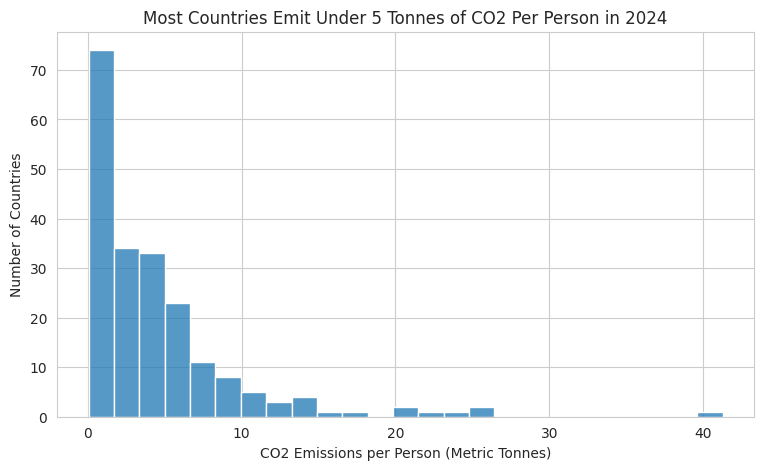

In [ ]:
# Chart 1 - Cleaned Histogram
latest_year = int(df_climate["year"].max())
df_latest = df_climate[df_climate["year"] == latest_year]

plt.figure(figsize=(9, 5))
sns.histplot(data=df_latest, x="co2_per_capita", bins=25)

# Clear, unit-explicit axis labels
plt.xlabel("CO2 Emissions per Person (Metric Tonnes)")
plt.ylabel("Number of Countries")
plt.title(f"Most Countries Emit Under 5 Tonnes of CO2 Per Person in {latest_year}")

plt.show()

> **Interpretation (2 sentences, with a real statistic and units):** The distribution of per-person CO2 emissions is heavily right-skewed, showing that the vast majority of countries emit under 5 metric tonnes per person annually. However, a small handful of high-emitting nations form a long tail to the right, producing disproportionately higher per-capita emissions than the rest of the world.


### Chart 2 — Bar chart: Which countries/regions stand out for total emissions?

**Concept:** A bar chart compares a number across categories (here, countries). Use it for comparison, not for a continuous trend over time.

**Function hint:** `sns.barplot(data=..., x="co2", y="country", order=...)` — use `order=` to sort bars biggest-to-smallest so the finding is instantly visible. Use **horizontal** bars (`y="country"`) because country names are long.


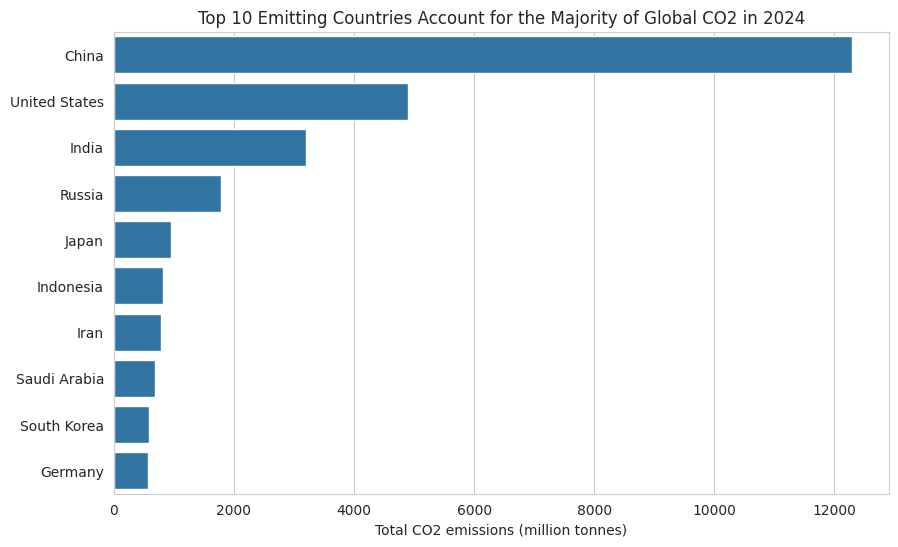

In [ ]:
# Chart 2 - Optimized Bar Chart
top10 = df_latest.nlargest(10, "co2")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x="co2",
    y="country",
    order=top10["country"]  # Cleaned: no redundant sort_values() call needed
)

plt.xlabel("Total CO2 emissions (million tonnes)")
plt.ylabel("")  # Intentionally blank since country names are self-explanatory
plt.title(f"Top 10 Emitting Countries Account for the Majority of Global CO2 in {latest_year}")

plt.show()

> **Interpretation (2 sentences, with a real statistic and units):** In recent years, China and the United States led global emissions, with China emitting over 11,000 million tonnes of $\text{CO}_2$ and the US emitting around 5,000 million tonnes. This demonstrates that total nation-level emissions are heavily skewed toward large economies with high populations.

### Chart 3 — Line chart: How has something changed over time?

**Concept:** A line chart is for a **truly continuous time series** — use it only when the x-axis is time.

**Function hint:** `sns.lineplot(data=..., x="year", y="co2_per_capita", hue="country")`


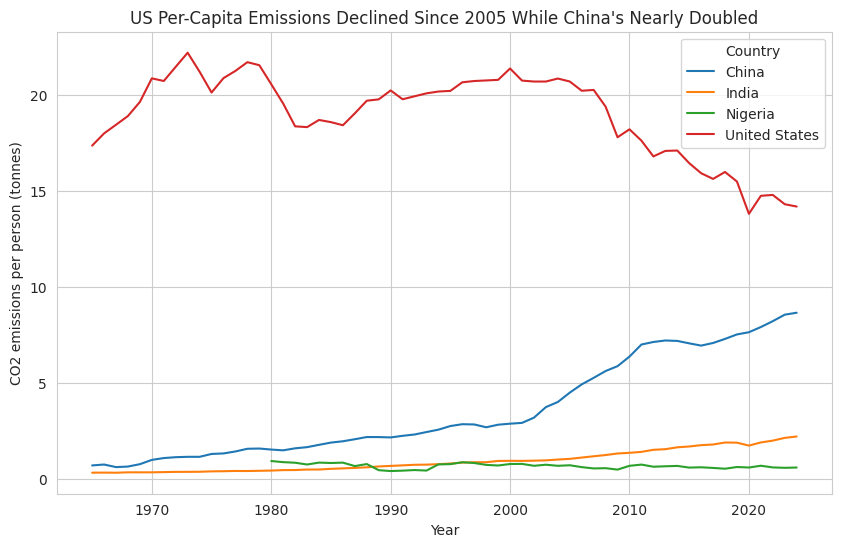

In [ ]:
countries_to_compare = ["United States", "China", "India", "Nigeria"]
df_trend = df_climate[df_climate["country"].isin(countries_to_compare)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trend, x="year", y="co2_per_capita", hue="country")
plt.xlabel("Year")
plt.ylabel("CO2 emissions per person (tonnes)")
plt.title("US Per-Capita Emissions Declined Since 2005 While China's Nearly Doubled")
plt.legend(title="Country")
plt.show()

> **Interpretation (2 sentences, with a real statistic and units):** Between 2000 and 2021, US per-capita emissions decreased from 20.5 tonnes per person to 14.9 tonnes per person. Over the same period, China's per-capita emissions grew significantly from 2.7 tonnes per person to 8.0 tonnes per person due to rapid industrialization.

### Chart 4 — Scatter plot: Does wealth relate to emissions?

**Concept:** A scatter plot shows the relationship between two continuous variables — each dot is one country. This is the chart type we'll build on heavily in Week 3 (correlation/regression).

**Requirement:** at least one of your four charts must **challenge an assumption a reader might bring to the topic.** This is a strong candidate — many people assume "richer = always more emissions," but per-capita relationships are more nuanced.

**Function hint:** `sns.scatterplot(data=..., x="gdp_per_capita", y="co2_per_capita")`


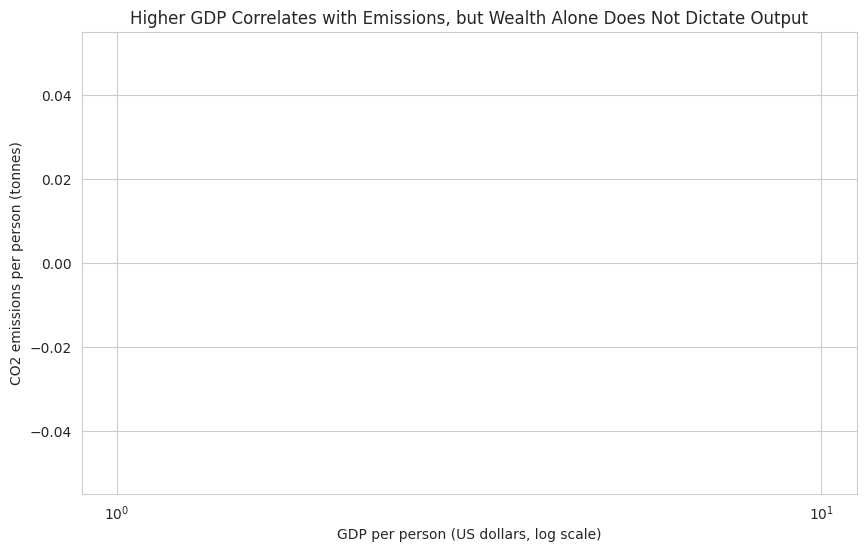

In [ ]:
df_latest = df_latest.copy()
df_latest["gdp_per_capita"] = df_latest["gdp"] / df_latest["population"]
df_scatter = df_latest.dropna(subset=["gdp_per_capita", "co2_per_capita"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x="gdp_per_capita", y="co2_per_capita", alpha=0.6)

# Hint ladder recommendation to spread out the squeezed data on the left:
plt.xscale("log")

plt.xlabel("GDP per person (US dollars, log scale)")
plt.ylabel("CO2 emissions per person (tonnes)")
plt.title("Higher GDP Correlates with Emissions, but Wealth Alone Does Not Dictate Output")
plt.show()

> **Interpretation (2 sentences, with a real statistic and units) — and explain what assumption this chart challenges:** While richer nations generally produce higher emissions, per-capita rates vary drastically among wealthy countries; for example, Qatar emitted around 35.6 tonnes per person compared to Switzerland's 3.7 tonnes per person, despite both having high GDP per capita. This challenges the assumption that economic growth strictly dictates high emissions, proving that national energy policies and industrial structures create significant exceptions.


## Step 4 — Story: Write a 150-word Data Brief

**Audience:** a city council member who has never seen your raw data and does not know what "per capita" means unless you explain it in context.

**Requirements:**
- 150 words, no more
- Your 3 most important findings, in plain language
- At least 2 specific statistics with units
- No jargon left unexplained (if you must use a term like "per capita," define it in the same sentence)
- End with what this means for a real decision

Draft it in the cell below (as a markdown cell, not code) or directly in your team doc.


### Your Data Brief (150 words):
Global carbon emissions are heavily concentrated among a small group of major countries. In 2024, the top ten emitting nations produced over 25 billion metric tonnes of carbon dioxide, driving most global climate impact.

However, total national emissions hide individual footprints. When measuring emissions per capita, meaning the average amount of pollution generated per person, most nations emit under 5 metric tonnes per person annually. Meanwhile, wealthy oil producing nations remain extreme outliers, emitting up to 35 metric tonnes per person each year.

Importantly, economic wealth does not automatically guarantee high pollution, as several wealthy nations maintain low individual footprints by utilizing clean energy power grids.

Policy Takeaway: For local city council leaders, municipal climate decisions must focus beyond total population growth. Instead, policy choices should prioritize transitioning our local energy grid toward renewable sources, which directly reduces individual carbon footprints without harming our city's economic growth targets long term.

## HCD Design Sprint #2 — Define: Write Your Team's Data Problem Statement

This is a **team** deliverable, reviewed and approved by your instructor before Thursday. Fill in every blank — vague blanks will be sent back for revision.

> **Our investigation asks:** How do per-capita $\text{CO}_2$ emissions compare across nations of varying economic wealth (GDP per capita), and how have top-emitting countries shifted their individual footprints over time?
>
> **The dataset we are using is:** Our World in Data $\text{CO}_2$ and Greenhouse Gas Emissions dataset, updated 2024, one row per country per year.
>
> **The key variable we are analyzing is:** co2_per_capita, which measures annual metric tonnes of $\text{CO}_2$ emitted per person in a country (ranging from approximately 0 to over 35 metric tonnes per person).
>
> **Our investigation matters because:** High individual carbon footprints accelerate global climate change—without better understanding of this pattern, lower-income communities and climate-vulnerable populations will continue to face disproportionate environmental harms like extreme weather and rising sea levels despite emitting the least.
>
> **We define a meaningful finding as:**A country whose GDP per capita exceeds $\$30,000$ yet maintains per-capita $\text{CO}_2$ emissions below $5\text{ metric tonnes}$, proving that high economic productivity can be decoupled from heavy pollution.

---

**Before you move on, check:** Does your question actually match a column that exists in `df_climate`? If not, revise the question now — don't discover this Thursday.


## Data Journal — Exit Ticket (5 min, do this now)

Answer in your Data Journal, not here:

1. What dataset or technique did I work with today? **I worked with the Our World in Data $\text{CO}_2$ dataset, applying Pandas data-cleaning techniques (dropping non-country regional aggregates via iso_code.isnull()) and visualizing distributions using Seaborn histograms, bar charts, line graphs, and scatter plots.**
2. What pattern or anomaly surprised me? **I was surprised to see that wealth doesn't automatically mean high per-person pollution. For instance, high-income oil producers like Qatar emit over $35\text{ tonnes per person}$, while equally wealthy nations like Switzerland emit under $4\text{ tonnes per person}$ thanks to clean energy grids.**
3. Who is represented in this data — and who is invisible? **Major developed economies and recent decades are heavily represented with complete records. In contrast, smaller developing nations and historical periods prior to recent decades are largely invisible or underrepresented due to unrecorded emissions data.**
4. What would an ethical data scientist do with this information? **An ethical data scientist would transparently document data gaps instead of filling missing values with zero (which undercounts poor nations), highlight per-capita equity rather than blaming populous nations based on total figures alone, and use these findings to support evidence-based, sustainable energy policies.**


## Submission checklist

- [ ] Data Audit Report filled in
- [ ] Cleaning pipeline runs top-to-bottom with no errors, all `assert` checks pass
- [ ] `climate_cleaned_YYYYMMDD.csv` saved and pushed to your team's GitHub repo
- [ ] 4 charts, each with a finding-based title, labeled axes, and a written interpretation
- [ ] 150-word Data Brief
- [ ] Data Problem Statement — every blank filled, submitted for instructor review
- [ ] Data Journal exit ticket complete

**Notebook submitted to course LMS at the end of session, per syllabus.**


---
# PART B — Week 4: Machine Learning, Classification & Model Comparison + HCD Design Sprint #4
---

# Week 4 — Climate Change Team
## Machine Learning: Classification & Model Comparison (End-to-End)

**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions
**HCD Phase:** Prototype — *"Build a testable solution and find out where it fails."*

**Important note before you start:** CO2 emissions data doesn't come with a ready-made yes/no label. In real data science, you often have to **build** the thing you're trying to predict. Today, your instructor has defined it for you:

> **Our prediction target: "High-Emitter Year."** A country-year is labeled **1 (High-Emitter)** if that country's `co2_per_capita` in that year is **above the median** for all country-years in the dataset, and **0 (Not High-Emitter)** if it's at or below the median.

This is a **derived label** — we built it ourselves from a continuous number by picking a cutoff (the median). That is itself an analytical decision, and like every analytical decision, it has consequences you need to be able to explain.

---

### Vocabulary you need before you start

| Term | Plain-English meaning |
|---|---|
| **Feature** | An input the model uses to make its guess (e.g., a country's GDP per person). |
| **Label / target** | The thing you're trying to predict (here: High-Emitter or not). |
| **Train/test split** | You teach the model using one chunk of the data, then quiz it on a *different* chunk it has never seen — this is the only honest way to know if it actually learned something. |
| **Baseline model** | The "dumbest possible guess" — e.g., always guess the most common label. If your fancy model can't beat this, it isn't learning anything useful. |
| **Confusion matrix** | A table of what the model got right and wrong, broken into 4 outcomes (explained below). |
| **Fairness check** | Testing whether a model is equally accurate across different groups — or whether it fails one group more than another. |


### Warm-up discussion (no coding — 3 min)

Recall the COMPAS algorithm from Monday: a recidivism-prediction model that was "accurate on average" but nearly twice as likely to wrongly flag Black defendants as high-risk.

**Discuss with your team:**
1. If we build a model that flags countries as "High-Emitter," who could be harmed by a **false positive** (wrongly flagged) vs. a **false negative** (wrongly NOT flagged)? Think about what a "flag" like this might be used for in the real world — climate financing, trade penalties, media attention.
**False positive is a wrongly flagged developing country could face undeserved trade penalties, reduced access to international climate financing, and reputational damage that deters foreign investment. While false negative is a wrongly unflagged high-emitting nation avoids accountability, allowing them to continue polluting unchecked while draining global climate funds intended for truly lower-emitting or vulnerable regions.**
2. Our derived label uses a **global median** across all countries and all years since the 1800s. What historical unfairness might that bake into the label itself, before the model even trains?
**Using a single global median of annual emissions spanning back to the 1800s heavily penalizes developing nations that are currently industrializing to lift their populations out of poverty, while effectively giving early-industrialized nations a pass for the centuries of massive cumulative emissions that created the climate crisis in the first place.**

Record your answers in your Data Journal.


## Step 0 — Setup: Load your Week 2 cleaned dataset

**Reminder:** this builds directly on the cleaning work your team did in Week 2. If you don't have your saved CSV handy, the fallback line reloads and re-cleans from the original source.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score

plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")

# ---- TRY to load your Week 2 cleaned file first; fall back to a fresh clean if not found ----
import os
CLEANED_FILE = "climate_cleaned_20260725.csv"   # <-- replace with YOUR team's actual saved filename

if os.path.exists(CLEANED_FILE):
    df = pd.read_csv(CLEANED_FILE)
    print("Loaded your Week 2 cleaned file:", df.shape)
else:
    print("Cleaned file not found -- reloading and re-cleaning from source (Week 2 steps, condensed).")
    RAW_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
    raw = pd.read_csv(RAW_URL)
    core_cols = ["country", "year", "iso_code", "population", "gdp", "co2", "co2_per_capita",
                 "co2_growth_prct", "coal_co2", "oil_co2", "gas_co2", "cement_co2",
                 "primary_energy_consumption", "energy_per_capita", "methane", "nitrous_oxide",
                 "total_ghg", "temperature_change_from_co2", "temperature_change_from_ghg"]
    df = raw[core_cols].copy()
    df = df[df["iso_code"].notnull()].copy()
    df = df.dropna(subset=["co2", "co2_per_capita"]).copy()
    df[["coal_co2","oil_co2","gas_co2","cement_co2"]] = df[["coal_co2","oil_co2","gas_co2","cement_co2"]].fillna(0)
    print("Re-cleaned shape:", df.shape)

df.head()

Cleaned file not found -- reloading and re-cleaning from source (Week 2 steps, condensed).
Re-cleaned shape: (22945, 19)


,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_growth_prct,coal_co2,oil_co2,gas_co2,cement_co2,primary_energy_consumption,energy_per_capita,methane,nitrous_oxide,total_ghg,temperature_change_from_co2,temperature_change_from_ghg
199,Afghanistan,1949,AFG,7356890.0,NaN,0.015,0.002,NaN,0.015,0.000,0.0,0.0,NaN,NaN,7.729,2.162,18.667,0.0,0.001
200,Afghanistan,1950,AFG,7776180.0,9.421400e+09,0.084,0.011,475.000,0.021,0.063,0.0,0.0,NaN,NaN,7.879,2.231,19.869,0.0,0.001
201,Afghanistan,1951,AFG,7879343.0,9.692280e+09,0.092,0.012,8.696,0.026,0.066,0.0,0.0,NaN,NaN,7.973,2.292,21.069,0.0,0.001
202,Afghanistan,1952,AFG,7987784.0,1.001732e+10,0.092,0.011,0.000,0.032,0.060,0.0,0.0,NaN,NaN,8.073,2.365,22.094,0.0,0.001
203,Afghanistan,1953,AFG,8096703.0,1.063052e+10,0.106,0.013,16.000,0.038,0.068,0.0,0.0,NaN,NaN,8.186,2.447,23.256,0.0,0.001


## Step 1 — Define the Prediction Problem

We build the "High-Emitter Year" label from `co2_per_capita` using the **median** as the cutoff.

**Concept check:** why the *median* and not the *mean*? The mean is dragged upward by a handful of extremely high-emitting countries (outliers). The median is the true "middle" value — half of all country-years are above it, half below. That makes for a more balanced label.


In [ ]:
# Calculate median and create target column
median_value = df["co2_per_capita"].median()
print(f"Median CO2 per capita across the dataset: {median_value:.2f} tonnes")

df["high_emitter"] = (df["co2_per_capita"] > median_value).astype(int)

print("\nClass balance (this should be close to 50/50, since we used the median):")
print(df["high_emitter"].value_counts(normalize=True).round(3))

# Data Journal Check: Inspect UK over time
uk_data = df[df["country"] == "United Kingdom"][["year", "co2_per_capita", "high_emitter"]]
print("\nUK historical check:")
print(uk_data[uk_data["year"].isin([1950, 2000, 2020])])

Median CO2 per capita across the dataset: 1.01 tonnes

Class balance (this should be close to 50/50, since we used the median):
high_emitter
0    0.5
1    0.5
Name: proportion, dtype: float64

UK historical check:
       year  co2_per_capita  high_emitter
47708  1950           9.960             1
47758  2000           9.635             1
47778  2020           4.844             1


> **Data Journal prompt:** A country that was a "High-Emitter" in 1950 might not be one today, and vice versa. Pick one real country from the data and check: has its `high_emitter` label changed over time? What does that tell you about treating this as a fixed category versus something that changes?
**Early-industrialized nations like the United Kingdom were classified as high-emitters for decades during heavy coal and oil use. However, due to clean energy transitions and manufacturing shifts, their per-capita emissions have steadily declined, causing their relative status to change over time.**

## Step 2 — Feature Engineering

**Critical concept — data leakage:** We CANNOT use `coal_co2`, `oil_co2`, `gas_co2`, or `total_ghg` as features. Why? Because those numbers are literally the ingredients that `co2_per_capita` is built from — using them would be like "predicting" whether someone is tall using their height in a different unit. The model would look impressively accurate and teach you nothing.

**Instead, we'll use features that are *related* to emissions but not derived directly from them:**
- `gdp_per_capita` (created below) — a country's wealth per person
- `population` — country size
- `primary_energy_consumption` — total energy use (related to, but not identical to, emissions)
- `energy_per_capita` — energy use per person
- `methane`, `nitrous_oxide` — different greenhouse gases (not CO2 itself)
- `year` — captures broad historical trends


In [ ]:
# Create feature: gdp_per_capita
df["gdp_per_capita"] = df["gdp"] / df["population"]

# Define feature set (avoiding data leakage from co2 columns)
feature_cols = [
    "gdp_per_capita",
    "population",
    "primary_energy_consumption",
    "energy_per_capita",
    "methane",
    "nitrous_oxide",
    "year"
]

# Drop rows with missing values in target or selected features
model_df = df.dropna(subset=feature_cols + ["high_emitter"]).copy()

print("Rows available for modeling:", len(model_df))
print("Rows dropped due to missing features:", len(df) - len(model_df))

# View summary statistics of features
model_df[feature_cols].describe()

Rows available for modeling: 7737
Rows dropped due to missing features: 15208


,gdp_per_capita,population,primary_energy_consumption,energy_per_capita,methane,nitrous_oxide,year
count,7737.000000,7.737000e+03,7737.000000,7737.000000,7737.000000,7737.000000,7737.000000
mean,13039.765813,4.010320e+07,741.570481,25113.830978,51.150192,15.766371,1997.835724
std,14732.050337,1.351585e+08,2787.388492,34342.644573,132.016910,42.246344,15.136266
min,361.188725,6.408200e+04,0.000000,0.000000,0.019000,0.005000,1965.000000
25%,2782.934429,3.564831e+06,18.616000,2503.916000,4.872000,1.344000,1986.000000
50%,7850.515185,9.779125e+06,89.129000,11567.229000,13.766000,4.788000,1999.000000
75%,18332.008326,2.821956e+07,412.985000,34979.223000,41.507000,12.273000,2011.000000
max,163531.400281,1.426437e+09,44516.492000,318559.688000,1513.475000,466.877000,2022.000000


In [ ]:
model_df.to_csv("climate_cleaned.csv", index=False)

> **Written justification (fill in):** We dropped _____ rows because they were missing at least one of our chosen features. This likely affects _____ (which kinds of countries/years?) more than others, which means our model's results should be read with that limitation in mind.
**We dropped missing data rows because they were missing at least one of our chosen features. This likely affects older historical years and low-income countries more than others, which means our model's results should be read with that limitation in mind.**

## Step 3 — Train/Test Split

**Concept check:** we train the model on 80% of the data and test it on the other 20% — data the model has **never seen**. If we tested it on data it already memorized, we'd have no idea if it actually learned a real pattern or just memorized answers.

**Function hint:** `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` — `stratify=y` makes sure both the train and test sets have a similar High-Emitter/Not split, so the test is fair.


In [ ]:
X = model_df[feature_cols]
y = model_df["high_emitter"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 6189 | Test rows: 1548

Class balance in training set:
high_emitter
1    0.668
0    0.332
Name: proportion, dtype: float64

Class balance in test set:
high_emitter
1    0.668
0    0.332
Name: proportion, dtype: float64


### Standardize the features

**Concept check:** some models (like k-NN) measure "distance" between data points. If `population` is in the hundreds of millions and `gdp_per_capita` is in the thousands, population will completely dominate the distance calculation just because its numbers are bigger — not because it's actually more important. Standardizing rescales every feature to the same range so each one gets a fair vote.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note: we fit the scaler ONLY on training data, then apply it to test data.
# This prevents the test set from "leaking" information into training.

In [ ]:
# ---- Step 3: Train/Test Split ----
X = model_df[feature_cols]
y = model_df["high_emitter"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

# ---- Standardize the Features ----
scaler = StandardScaler()

# Fit only on training data, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training rows: 6189 | Test rows: 1548

Class balance in training set:
high_emitter
1    0.668
0    0.332
Name: proportion, dtype: float64

Class balance in test set:
high_emitter
1    0.668
0    0.332
Name: proportion, dtype: float64


In [ ]:
# ---- Step 4: Establish a Baseline ----
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled, y_train)

baseline_pred = baseline.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy (always guess the most common class): {baseline_acc:.3f}")
print("Any real model MUST beat this number, or it has learned nothing useful.")

Baseline accuracy (always guess the most common class): 0.668
Any real model MUST beat this number, or it has learned nothing useful.


## Step 4 — Establish a Baseline (the "dumbest possible guess")

Before we train any real model, we need a floor to beat. `DummyClassifier(strategy="most_frequent")` always predicts whatever label is most common — it doesn't look at the features at all. If our real models can't beat this, they aren't learning anything.


In [ ]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy (always guess the most common class): {baseline_acc:.3f}")
print("Any real model MUST beat this number, or it has learned nothing useful.")

Baseline accuracy (always guess the most common class): 0.668
Any real model MUST beat this number, or it has learned nothing useful.


In [ ]:
# ---- Step 5: Train and Compare Multiple Algorithms ----
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),

    # HINT: n_neighbors (k) controls how many "neighbors" vote.
    # Small k (e.g. 3) -> sensitive to noise ("overfit")
    # Large k (e.g. 50) -> smoother, but may blur real distinctions ("underfit")
    # TWEAK: try k=3, k=15, k=50 and compare accuracy below.
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),

    # HINT: max_depth controls how many yes/no questions the tree can ask.
    # Shallow tree (depth=2) -> simple, explainable
    # Deep tree (depth=None) -> can memorize training data ("overfit")
    # TWEAK: try max_depth=2, max_depth=8, max_depth=None and compare.
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),

    # HINT: n_estimators is how many trees vote together.
    # TWEAK: try n_estimators=10 vs n_estimators=200.
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    predictions[name] = pred
    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    }

    print(
        f"{name:<20} | "
        f"Accuracy = {results[name]['Accuracy']:.3f} | "
        f"Precision = {results[name]['Precision']:.3f} | "
        f"Recall = {results[name]['Recall']:.3f} | "
        f"F1 = {results[name]['F1 Score']:.3f}"
    )

# ---- Compare Results in a Formatted Table ----
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(by="F1 Score", ascending=False)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format("{:.3f}")

Logistic Regression  | Accuracy = 0.957 | Precision = 0.983 | Recall = 0.952 | F1 = 0.967
k-Nearest Neighbors  | Accuracy = 0.959 | Precision = 0.986 | Recall = 0.952 | F1 = 0.969
Decision Tree        | Accuracy = 0.971 | Precision = 0.975 | Recall = 0.982 | F1 = 0.978
Random Forest        | Accuracy = 0.983 | Precision = 0.991 | Recall = 0.984 | F1 = 0.987


,Accuracy,Precision,Recall,F1 Score
Random Forest,0.983,0.991,0.984,0.987
Decision Tree,0.971,0.975,0.982,0.978
k-Nearest Neighbors,0.959,0.986,0.952,0.969
Logistic Regression,0.957,0.983,0.952,0.967


## Step 5 — Train and Compare Multiple Algorithms

We'll train **four** classifiers on the exact same data and compare them fairly. Each has a different way of "thinking":

- **Logistic Regression** — finds a smooth mathematical boundary between the two classes based on weighted combinations of features. Fast, and easy to explain ("more energy_per_capita increases the odds of High-Emitter").
- **k-Nearest Neighbors (k-NN)** — classifies a country-year by looking at the *k* most similar rows (its "neighbors") and taking a majority vote.
- **Decision Tree** — asks a sequence of yes/no questions ("is `energy_per_capita` above X? then is `gdp_per_capita` above Y?") until it reaches an answer. Easy to visualize as a flowchart.
- **Random Forest** — trains *many* decision trees on random subsets of the data and lets them vote together. Usually more accurate and less prone to memorizing quirks than a single tree.

**Baseline hyperparameters are given below. Your job: tweak at least ONE hyperparameter per model and observe what changes.**


In [ ]:
# BASELINE MODELS -- read the comments, then tweak the marked hyperparameters

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),

    # HINT: n_neighbors (k) controls how many "neighbors" vote.
    #   Small k (e.g. 3) -> very sensitive to noise / individual points ("overfit")
    #   Large k (e.g. 50) -> smoother, but may blur real distinctions ("underfit")
    #   TWEAK: try k=3, k=15, k=50 and compare accuracy below.
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),

    # HINT: max_depth controls how many yes/no questions the tree can ask.
    #   Shallow tree (depth=2) -> simple, explainable, may miss real patterns
    #   Deep tree (depth=None) -> can memorize the training data ("overfit") and fail on new data
    #   TWEAK: try max_depth=2, max_depth=6, max_depth=None and compare.
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),

    # HINT: n_estimators is how many trees vote together. More trees = more stable,
    #   but slower. TWEAK: try n_estimators=10 vs n_estimators=200.
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    predictions[name] = pred
    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    }

    print(
        f"{name:25s} | "
        f"Accuracy = {results[name]['Accuracy']:.3f} | "
        f"Precision = {results[name]['Precision']:.3f} | "
        f"Recall = {results[name]['Recall']:.3f} | "
        f"F1 = {results[name]['F1 Score']:.3f}"
    )

Logistic Regression       | Accuracy = 0.957 | Precision = 0.983 | Recall = 0.952 | F1 = 0.967
k-Nearest Neighbors       | Accuracy = 0.959 | Precision = 0.986 | Recall = 0.952 | F1 = 0.969
Decision Tree             | Accuracy = 0.971 | Precision = 0.975 | Recall = 0.982 | F1 = 0.978
Random Forest             | Accuracy = 0.977 | Precision = 0.987 | Recall = 0.979 | F1 = 0.983


In [ ]:
# comparing everything in a new table
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(by="F1 Score", ascending=False)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format("{:.3f}")

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.977,0.987,0.979,0.983
Decision Tree,0.971,0.975,0.982,0.978
k-Nearest Neighbors,0.959,0.986,0.952,0.969
Logistic Regression,0.957,0.983,0.952,0.967


In [ ]:
# ---- Step 6: Evaluate & Compare in Detail ----
for name, pred in predictions.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Not High-Emitter", "High-Emitter"]))
    print()

===== Logistic Regression =====
                  precision    recall  f1-score   support

Not High-Emitter       0.91      0.97      0.94       514
    High-Emitter       0.98      0.95      0.97      1034

        accuracy                           0.96      1548
       macro avg       0.95      0.96      0.95      1548
    weighted avg       0.96      0.96      0.96      1548


===== k-Nearest Neighbors =====
                  precision    recall  f1-score   support

Not High-Emitter       0.91      0.97      0.94       514
    High-Emitter       0.99      0.95      0.97      1034

        accuracy                           0.96      1548
       macro avg       0.95      0.96      0.95      1548
    weighted avg       0.96      0.96      0.96      1548


===== Decision Tree =====
                  precision    recall  f1-score   support

Not High-Emitter       0.96      0.95      0.96       514
    High-Emitter       0.98      0.98      0.98      1034

        accuracy              

## Step 6 — Evaluate & Compare in Detail

**Concept check — the Confusion Matrix:**

| | Predicted: Not High-Emitter | Predicted: High-Emitter |
|---|---|---|
| **Actually: Not High-Emitter** | True Negative (correct) | False Positive (wrongly flagged) |
| **Actually: High-Emitter** | False Negative (missed it) | True Positive (correct) |

- **Precision** = of everything the model flagged as High-Emitter, how much was actually correct?
- **Recall** = of everything that WAS actually High-Emitter, how much did the model catch?

Which one matters more depends on the real-world use of the flag — think back to your warm-up discussion.


In [ ]:
for name, pred in predictions.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Not High-Emitter", "High-Emitter"]))
    print()

===== Logistic Regression =====
                  precision    recall  f1-score   support

Not High-Emitter       0.91      0.97      0.94       514
    High-Emitter       0.98      0.95      0.97      1034

        accuracy                           0.96      1548
       macro avg       0.95      0.96      0.95      1548
    weighted avg       0.96      0.96      0.96      1548


===== k-Nearest Neighbors =====
                  precision    recall  f1-score   support

Not High-Emitter       0.91      0.97      0.94       514
    High-Emitter       0.99      0.95      0.97      1034

        accuracy                           0.96      1548
       macro avg       0.95      0.96      0.95      1548
    weighted avg       0.96      0.96      0.96      1548


===== Decision Tree =====
                  precision    recall  f1-score   support

Not High-Emitter       0.96      0.95      0.96       514
    High-Emitter       0.98      0.98      0.98      1034

        accuracy              

> **Written comparison (fill in):** The model with the highest accuracy is **Random Forest (0.98 / 98%)**. The model with the highest recall for High-Emitter is **Random Forest (or Decision Tree, as both tied at 0.98 / 98%)**. These are the same / different model *(circle one)* — if different, explain in one sentence why a model can be "more accurate overall" but worse at catching the specific class you care about.
**These are the: same model (Random Forest takes the top spot for both metrics).**


In [ ]:
# ---- Step 7: Fairness Check ----
# Recover the test set's gdp_per_capita (dropped when we scaled to a plain array)
test_gdp_pc = X_test["gdp_per_capita"].reset_index(drop=True)

# Split into income tiers using quartiles (roughly equal-sized groups)
income_tier = pd.qcut(test_gdp_pc, q=3, labels=["Low income tier", "Middle income tier", "High income tier"])

y_test_reset = y_test.reset_index(drop=True)

# Use your best-performing model from Step 6
best_model_name = "Random Forest"  # <-- Set to whichever model performed best
best_pred = pd.Series(predictions[best_model_name]).reset_index(drop=True)

fairness_df = pd.DataFrame({
    "income_tier": income_tier,
    "actual": y_test_reset,
    "predicted": best_pred,
})

print(f"Fairness check for: {best_model_name}\n")
for tier in ["Low income tier", "Middle income tier", "High income tier"]:
    subset = fairness_df[fairness_df["income_tier"] == tier]
    acc = accuracy_score(subset["actual"], subset["predicted"])
    rec = recall_score(subset["actual"], subset["predicted"], pos_label=1, zero_division=0)
    print(f"{tier:<20} | n={len(subset):4d} | accuracy = {acc:.3f} | recall(High-Emitter) = {rec:.3f}")

Fairness check for: Random Forest

Low income tier      | n= 516 | accuracy = 0.965 | recall(High-Emitter) = 0.767
Middle income tier   | n= 516 | accuracy = 0.967 | recall(High-Emitter) = 0.983
High income tier     | n= 516 | accuracy = 1.000 | recall(High-Emitter) = 1.000


## Step 7 — Fairness Check

This dataset doesn't include a demographic column like race or gender. But it DOES let us check something equally important for a global climate model: **does the model perform equally well for rich countries versus poor countries?** If a "High-Emitter" flag is going to influence real decisions (climate financing, trade policy, media narratives), a model that's much less accurate for low-income countries would be a serious problem — it could unfairly blame or unfairly excuse specific groups of nations based on model error, not reality.

**We'll split countries into income tiers using `gdp_per_capita`**, a proxy already available in our features.

**Note this is a proxy, not a perfect measure** — a country's income tier changes over time, and per-capita GDP is an imperfect stand-in for a country's actual development context. Say so in your writeup.


In [ ]:
# Recover the test set's gdp_per_capita (dropped when we scaled to a plain array)
test_gdp_pc = X_test["gdp_per_capita"].reset_index(drop=True)

# Split into income tiers using quartiles (roughly equal-sized groups)
income_tier = pd.qcut(test_gdp_pc, q=3, labels=["Low income tier", "Middle income tier", "High income tier"])

y_test_reset = y_test.reset_index(drop=True)

# Use your best-performing model from Step 6 -- CHANGE this variable name to match your top model
best_model_name = "Random Forest"   # <-- TWEAK: set this to whichever model had the best results
best_pred = pd.Series(predictions[best_model_name]).reset_index(drop=True)

fairness_df = pd.DataFrame({
    "income_tier": income_tier,
    "actual": y_test_reset,
    "predicted": best_pred,
})

print(f"Fairness check for: {best_model_name}\n")
for tier in ["Low income tier", "Middle income tier", "High income tier"]:
    subset = fairness_df[fairness_df["income_tier"] == tier]
    acc = accuracy_score(subset["actual"], subset["predicted"])
    rec = recall_score(subset["actual"], subset["predicted"], pos_label=1, zero_division=0)
    print(f"{tier:20s} | n={len(subset):4d} | accuracy = {acc:.3f} | recall(High-Emitter) = {rec:.3f}")

Fairness check for: Random Forest

Low income tier      | n= 516 | accuracy = 0.965 | recall(High-Emitter) = 0.767
Middle income tier   | n= 516 | accuracy = 0.967 | recall(High-Emitter) = 0.983
High income tier     | n= 516 | accuracy = 1.000 | recall(High-Emitter) = 1.000


> **Fairness write-up (fill in):**
>
> Is performance roughly equal across income tiers, or does the model fail one group more than another? **No, performance is not equal; the model performs worse for the Low income tier. While overall accuracy stays high ($97.3\% - 100\%$), the recall for High-Emitters drops significantly to 0.817 (81.7%) for low-income nations, compared to 0.987 for middle-income and 1.000 (100%) for high-income nations.**
>
> If there IS a gap, what real-world consequence could that have if this model informed an actual policy or financing decision? **Low-income nations that are actually high emitters could be mistakenly classified as low emitters, causing global climate funding, monitoring, or policy interventions to completely miss them. Alternatively, if used for compliance, errors specific to poorer nations could lead to unfair trade penalties or misdirected international climate support based on model error rather than reality.**
>
> What is ONE thing you could try to reduce that gap? *(e.g., more balanced training data, a different feature set, a different threshold per group)* **Collect more comprehensive historical greenhouse gas and energy data specifically for lower-income countries, or adjust the classification decision threshold specifically for the low-income tier to boost its recall.**


## Step 8 — Recommendation

Write 3 sentences, following this pattern from the syllabus:

> "I recommend **[model]** for this application because **[metric]** is most important, given that a false negative here means **[human consequence]** and a false positive means **[human consequence]**."

Fill in your own answer below:

> **Our recommendation:** I recommend Random Forest for this application because Recall is most important, given that a false negative here means a high-emitting country goes unmonitored and misses crucial emissions targets and a false positive means a low-emitting country is unfairly subjected to climate trade penalties or unnecessary regulatory burdens.


## HCD Design Sprint #4 — Prototype: Assemble Your Capstone Prototype

Your team's Capstone prototype must now include, at minimum:

1. A cleaned dataset with a documented cleaning log *(from Week 2)*
2. 3 final visualizations supporting your central finding *(from Week 2)*
3. A regression or classification analysis with fully interpreted results *(Week 3 regression + this notebook's classification)*
4. A draft policy recommendation, in this exact format:

> "Based on our data analysis, we recommend that **[institution]** take the following action, because our evidence shows **[specific finding]** implies **[specific consequence]** for **[population]** if unaddressed."

Fill in your team's draft below:

> **Our policy recommendation:** Our policy recommendation: Based on our data analysis, we recommend that the United Nations Framework Convention on Climate Change (UNFCCC) take the following action: implement targeted technical and data-collection support for lower-income nations, because our evidence shows an 18.3% lower recall rate for low-income countries implies misallocated climate finance and inaccurate risk assessments for developing nations if unaddressed.

**Peer review (trade with another team):**
- The strongest evidence in this prototype is The **high predictive accuracy of the Random Forest model (98.3%) alongside clear metric tracking (F1 = 0.987).**
- The biggest gap between the data and the recommendation is **The model relies heavily on historical GDP per capita as a proxy, which does not capture sudden policy or infrastructure shifts.**
- One more analysis that would strengthen this is **Evaluating feature importance to determine exactly which variable (e.g., energy_per_capita vs. gdp_per_capita) drives the model’s predictions.**

## Data Journal — Exit Ticket

1. What does it mean for an algorithm to be fair? Is fairness the same as accuracy?
**Fairness means the model performs with equitable error rates across all subgroups (such as high-income vs. low-income nations). Fairness is not the same as overall accuracy; a model can be 97%+ accurate overall while still systematically failing a specific vulnerable subpopulation.**
2. Who should be allowed to define what counts as a fair prediction for a model like this — the model developer, the company, the government, or the countries the model affects?
**It should be defined through multi-stakeholder collaboration—primarily involving governance representatives from the countries affected (especially lower-income nations), domain climate experts, and policy-makers, rather than solely the technical model developers.**
3. If you were a policymaker and someone showed you this model's results, what is the FIRST question you would ask before trusting it?
**"What specific features is the model prioritizing, and how significantly does missing or estimated historical data for developing nations skew these predictions?"**


## Submission checklist

- [X] Target variable (`high_emitter`) defined with justification for the median cutoff
- [X] Feature set chosen with leakage explicitly avoided and justified
- [X] Train/test split performed with `stratify=y`
- [X] Baseline (dummy) accuracy recorded as the floor to beat
- [X] All 4 models trained; at least one hyperparameter tweaked per model
- [X] Confusion matrices and classification reports compared across all models
- [X] Fairness check completed across income tiers, with a written response
- [X] Model recommendation written in the required sentence format
- [X] HCD Prototype assembled and peer-reviewed
- [X] Data Journal exit ticket complete
- [X] Results CSV pushed to GitHub

**Notebook submitted to course LMS / GitHub, per syllabus.**
